In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


In [3]:
# Baca file dari folder yang benar
df = pd.read_csv('/content/drive/MyDrive/MY SEMEST8R/DATA VALID/HASIL DATA PER GOLONGAN.csv')


In [4]:
df = pd.read_csv('/content/drive/MyDrive/MY SEMEST8R/DATA VALID/HASIL DATA PER GOLONGAN.csv')
print(df.columns)


Index(['TAHUN', 'BULAN', 'GOLONGAN I ', 'GOLONGAN II ', 'GOLONGAN III '], dtype='object')


In [5]:
import pandas as pd

# Asumsi df sudah dibaca tanpa parse_dates
df['Tanggal'] = pd.to_datetime(df['TAHUN'].astype(str) + '-' + df['BULAN'].astype(str).str.zfill(2) + '-01')

print(df[['TAHUN', 'BULAN', 'Tanggal']].head())


   TAHUN  BULAN    Tanggal
0   2022      1 2022-01-01
1   2022      2 2022-02-01
2   2022      3 2022-03-01
3   2022      4 2022-04-01
4   2022      5 2022-05-01


In [6]:
# 2. Drop baris yang tanggal kosong (kalau ada)
df = df.dropna(subset=['Tanggal'])

In [7]:
# 3. Sort berdasarkan tanggal (sebagai kolom dulu)
df = df.sort_values('Tanggal')

In [8]:
# 4. Set kolom 'Tanggal' jadi index
df = df.set_index('Tanggal')

# Sekarang bisa akses index dengan df.index, tapi tidak lagi dengan df['Tanggal']
print(df.index)

DatetimeIndex(['2022-01-01', '2022-02-01', '2022-03-01', '2022-04-01',
               '2022-05-01', '2022-06-01', '2022-07-01', '2022-08-01',
               '2022-09-01', '2022-10-01', '2022-11-01', '2022-12-01',
               '2023-01-01', '2023-02-01', '2023-03-01', '2023-04-01',
               '2023-05-01', '2023-06-01', '2023-07-01', '2023-08-01',
               '2023-09-01', '2023-10-01', '2023-11-01', '2023-12-01',
               '2024-01-01', '2024-02-01', '2024-03-01', '2024-04-01',
               '2024-05-01', '2024-06-01', '2024-07-01', '2024-08-01',
               '2024-09-01', '2024-10-01', '2024-11-01', '2024-12-01'],
              dtype='datetime64[ns]', name='Tanggal', freq=None)


In [9]:
df.index = pd.to_datetime(df.index)
df = df.asfreq('MS')


In [10]:
# Cek hasil
print(df.head())

            TAHUN  BULAN  GOLONGAN I   GOLONGAN II   GOLONGAN III 
Tanggal                                                           
2022-01-01   2022      1         3659        108649          33421
2022-02-01   2022      2         3039         89464          31321
2022-03-01   2022      3         3975        106186          40330
2022-04-01   2022      4         3117         83316          33130
2022-05-01   2022      5         4121        117199          39885


In [11]:
df.columns = df.columns.str.strip()  # buang spasi di kiri kanan nama kolom
data_golongan_3 = df['GOLONGAN III']


In [12]:
train = df.loc['2022-01-01':'2024-04-30', 'GOLONGAN III']
test = df.loc['2024-05-01':'2024-12-31', 'GOLONGAN III']

print(f'Data latih: {train.index[0]} sampai {train.index[-1]}')
print(f'Data uji: {test.index[0]} sampai {test.index[-1]}')


Data latih: 2022-01-01 00:00:00 sampai 2024-04-01 00:00:00
Data uji: 2024-05-01 00:00:00 sampai 2024-12-01 00:00:00


In [13]:
from statsmodels.tsa.stattools import adfuller

# Misalnya data_golongan_3 adalah hasil slicing golongan III
adf_result = adfuller(data_golongan_3.dropna())

# Cetak hasil ADF test lengkap
print("Hasil Uji Stasioneritas (ADF Test):")
print(f"ADF Statistic     : {adf_result[0]}")
print(f"p-value           : {adf_result[1]}")
print("Critical Values   :")
for key, value in adf_result[4].items():
    print(f"   {key} : {value}")

# Keputusan stasioner atau tidak
if adf_result[1] <= 0.05:
    print("Data sudah stasioner (p-value <= 0.05)")
    d = 0
else:
    print("Data belum stasioner (p-value > 0.05), perlu differencing")
    d = 1


Hasil Uji Stasioneritas (ADF Test):
ADF Statistic     : -1.9306870965822442
p-value           : 0.3177654528311752
Critical Values   :
   1% : -3.639224104416853
   5% : -2.9512301791166293
   10% : -2.614446989619377
Data belum stasioner (p-value > 0.05), perlu differencing


In [14]:
for i in range(d):
    data_golongan_3 = data_golongan_3.diff().dropna()


In [15]:
from statsmodels.tsa.stattools import adfuller

# Misalnya data_golongan_3 adalah hasil slicing golongan III
adf_result = adfuller(data_golongan_3.dropna())

# Cetak hasil ADF test lengkap
print("Hasil Uji Stasioneritas (ADF Test):")
print(f"ADF Statistic     : {adf_result[0]}")
print(f"p-value           : {adf_result[1]}")
print("Critical Values   :")
for key, value in adf_result[4].items():
    print(f"   {key} : {value}")

# Keputusan stasioner atau tidak
if adf_result[1] <= 0.05:
    print("Data sudah stasioner (p-value <= 0.05)")
    d = 0
else:
    print("Data belum stasioner (p-value > 0.05), perlu differencing")
    d = 1


Hasil Uji Stasioneritas (ADF Test):
ADF Statistic     : -11.311795125598968
p-value           : 1.2338249076890348e-20
Critical Values   :
   1% : -3.639224104416853
   5% : -2.9512301791166293
   10% : -2.614446989619377
Data sudah stasioner (p-value <= 0.05)


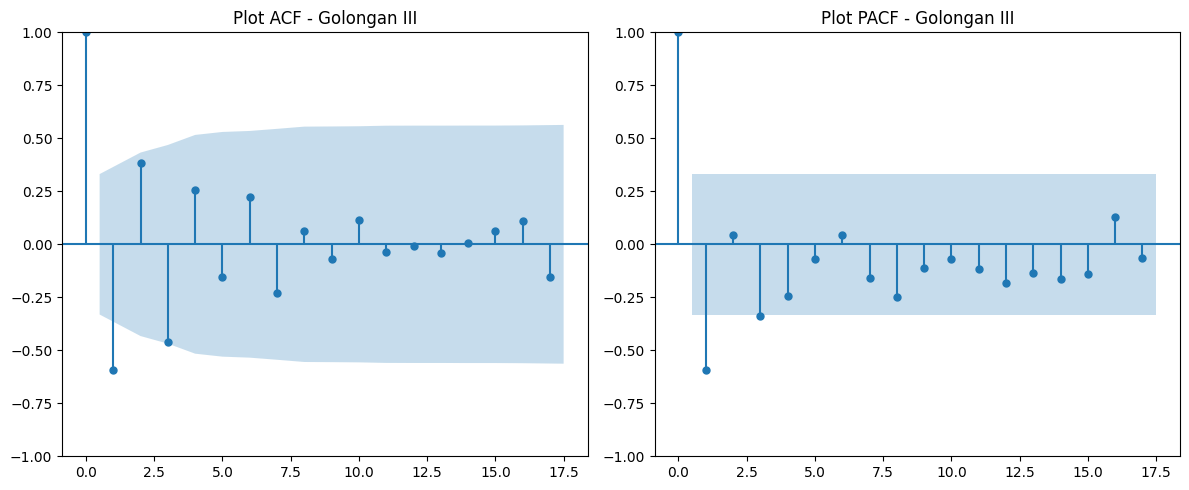

In [16]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plot_acf(data_golongan_3, lags=17, ax=plt.gca())
plt.title('Plot ACF - Golongan III')

plt.subplot(1, 2, 2)
plot_pacf(data_golongan_3, lags=17, ax=plt.gca(), method='ywm')
plt.title('Plot PACF - Golongan III')

plt.tight_layout()
plt.show()


In [17]:
from sklearn.metrics import mean_absolute_percentage_error

def grid_search_arima(df, p_max=2, d_max=1, q_max=2):
    best_aic = np.inf
    best_order = None
    best_model = None
    best_mape = np.inf

    for p in range(1, p_max + 1):
        for d in range(d_max + 1):
            for q in range(1, q_max + 1):
                try:
                    print(f'Mencoba model ARIMA({p},{d},{q})')
                    model = ARIMA(df, order=(p, d, q))
                    model_fit = model.fit()

                    pred = model_fit.fittedvalues
                    mape = mean_absolute_percentage_error(df, pred) * 100  # persen

                    print(f'MAPE: {mape:.2f}%')

                    aic_value = model_fit.aic

                    if aic_value < best_aic:
                        best_aic = aic_value
                        best_order = (p, d, q)
                        best_model = model_fit
                        best_mape = mape
                        print('--> Model ini disimpan sebagai terbaik sementara')

                except Exception as e:
                    print(f"Model ARIMA({p},{d},{q}) gagal: {e}")
                    continue

    return best_order, best_model, best_aic, best_mape

# Panggil fungsi di luar
best_order, best_model, best_aic, best_mape = grid_search_arima(train)

print(f'Parameter terbaik untuk GOLONGAN III (p,d,q): {best_order}')
print(f'AIC terbaik: {best_aic}')
print(f'MAPE terbaik: {best_mape:.2f}%')
print(f'Ringkasan model terbaik:\n{best_model.summary()}')

Mencoba model ARIMA(1,0,1)
MAPE: 7.11%
--> Model ini disimpan sebagai terbaik sementara
Mencoba model ARIMA(1,0,2)
MAPE: 6.80%
--> Model ini disimpan sebagai terbaik sementara
Mencoba model ARIMA(1,1,1)
MAPE: 10.09%
--> Model ini disimpan sebagai terbaik sementara
Mencoba model ARIMA(1,1,2)
MAPE: 8.87%
--> Model ini disimpan sebagai terbaik sementara
Mencoba model ARIMA(2,0,1)
MAPE: 7.04%
Mencoba model ARIMA(2,0,2)
MAPE: 7.00%
Mencoba model ARIMA(2,1,1)
MAPE: 9.35%
Mencoba model ARIMA(2,1,2)


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


MAPE: 8.60%
--> Model ini disimpan sebagai terbaik sementara
Parameter terbaik untuk GOLONGAN III (p,d,q): (2, 1, 2)
AIC terbaik: 509.54650247278306
MAPE terbaik: 8.60%
Ringkasan model terbaik:
                               SARIMAX Results                                
Dep. Variable:           GOLONGAN III   No. Observations:                   28
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -249.773
Date:                Sat, 31 May 2025   AIC                            509.547
Time:                        07:19:28   BIC                            516.026
Sample:                    01-01-2022   HQIC                           511.473
                         - 04-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1

In [18]:
# 1. Siapkan data test
test_gol3 = df.loc['2024-05-01':'2024-12-31', 'GOLONGAN III']

# 2. Prediksi data test pakai model terbaik dari train
forecast_test = best_model.forecast(steps=len(test_gol3))

# 3. Hitung MAPE di data test
from sklearn.metrics import mean_absolute_percentage_error
mape_test = mean_absolute_percentage_error(test_gol3, forecast_test) * 100
print(f'MAPE pada data testing: {mape_test:.2f}%')

# 4. Fit ulang model pakai seluruh data (train + test)
from statsmodels.tsa.arima.model import ARIMA
full_model = ARIMA(df['GOLONGAN III'], order=best_order)
full_model_fit = full_model.fit()

# 5. Forecast 24 bulan ke depan
forecast_24 = full_model_fit.forecast(steps=24)

last_date = df.index[-1]
forecast_dates_24 = [last_date + pd.DateOffset(months=i+1) for i in range(24)]

forecast_df_24 = pd.DataFrame({
    'Tanggal': forecast_dates_24,
    'Prediksi Konsumsi Air': forecast_24.values  # pakai .values untuk aman
})

print("Prediksi 24 Bulan ke Depan:")
print(forecast_df_24)


MAPE pada data testing: 6.75%
Prediksi 24 Bulan ke Depan:
      Tanggal  Prediksi Konsumsi Air
0  2025-01-01           46724.543044
1  2025-02-01           45097.356949
2  2025-03-01           46490.860741
3  2025-04-01           45372.080419
4  2025-05-01           46204.605681
5  2025-06-01           45646.798113
6  2025-07-01           45958.006684
7  2025-08-01           45854.761581
8  2025-09-01           45793.878826
9  2025-10-01           45974.230797
10 2025-11-01           45716.532275
11 2025-12-01           46014.344513
12 2026-01-01           45707.332100
13 2026-02-01           45999.581764
14 2026-03-01           45739.122361
15 2026-04-01           45957.197716
16 2026-05-01           45786.499563
17 2026-06-01           45909.403863
18 2026-07-01           45831.229369
19 2026-08-01           45870.146400
20 2026-09-01           45863.585142
21 2026-10-01           45845.282383
22 2026-11-01           45881.041967
23 2026-12-01           45834.645409


In [19]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_percentage_error

# Misal sudah punya data train dan test
train_gol3 = df.loc['2022-01-01':'2024-04-30', 'GOLONGAN III']
test_gol3 = df.loc['2024-05-01':'2024-12-31', 'GOLONGAN III']

# Range parameter yang mau kamu coba (sesuaikan aja)
p_values = [0, 1, 2, 3, 4]
d_values = [0, 1]
q_values = [0, 1, 2, 3, 4]

hasil = []

for p in p_values:
    for d in d_values:
        for q in q_values:
            try:
                model = ARIMA(train_gol3, order=(p,d,q))
                model_fit = model.fit()
                forecast_test = model_fit.forecast(steps=len(test_gol3))
                mape = mean_absolute_percentage_error(test_gol3, forecast_test) * 100
                hasil.append(((p,d,q), mape))
                print(f'ARIMA({p},{d},{q}) - MAPE: {mape:.2f}%')
            except Exception as e:
                print(f'ARIMA({p},{d},{q}) gagal: {e}')
                continue

# Cari parameter dengan MAPE terkecil
best_params = min(hasil, key=lambda x: x[1])
print(f'\nParameter terbaik: ARIMA{best_params[0]} dengan MAPE {best_params[1]:.2f}%')


ARIMA(0,0,0) - MAPE: 13.16%
ARIMA(0,0,1) - MAPE: 12.92%
ARIMA(0,0,2) - MAPE: 11.68%
ARIMA(0,0,3) - MAPE: 11.65%
ARIMA(0,0,4) - MAPE: 11.38%
ARIMA(0,1,0) - MAPE: 4.68%
ARIMA(0,1,1) - MAPE: 4.83%
ARIMA(0,1,2) - MAPE: 4.43%
ARIMA(0,1,3) - MAPE: 3.92%
ARIMA(0,1,4) - MAPE: 4.32%
ARIMA(1,0,0) - MAPE: 12.45%
ARIMA(1,0,1) - MAPE: 10.92%
ARIMA(1,0,2) - MAPE: 11.65%


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


ARIMA(1,0,3) - MAPE: 12.07%


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA(1,0,4) - MAPE: 6.13%
ARIMA(1,1,0) - MAPE: 4.80%
ARIMA(1,1,1) - MAPE: 4.09%
ARIMA(1,1,2) - MAPE: 4.72%
ARIMA(1,1,3) - MAPE: 5.03%
ARIMA(1,1,4) - MAPE: 6.38%
ARIMA(2,0,0) - MAPE: 10.50%
ARIMA(2,0,1) - MAPE: 10.17%
ARIMA(2,0,2) - MAPE: 10.86%


...

/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


ARIMA(4,1,2) - MAPE: 7.67%


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


ARIMA(4,1,3) - MAPE: 9.41%
ARIMA(4,1,4) - MAPE: 8.60%

Parameter terbaik: ARIMA(0, 1, 3) dengan MAPE 3.92%


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [20]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_percentage_error
import pandas as pd

# 1. Siapkan data test
test_gol3 = df.loc['2024-05-01':'2024-12-31', 'GOLONGAN III']

# 2. Fit model ARIMA(3,1,4) pada data latih
train_gol3 = df.loc['2022-01-01':'2024-04-30', 'GOLONGAN III']
best_order = (3, 1, 4)

model = ARIMA(train_gol3, order=best_order)
model_fit = model.fit()

# 3. Prediksi data test
forecast_test = model_fit.forecast(steps=len(test_gol3))

# 4. Hitung MAPE pada data test
mape_test = mean_absolute_percentage_error(test_gol3, forecast_test) * 100
print(f'MAPE pada data testing: {mape_test:.2f}%')

# 5. Fit ulang model ARIMA(3,1,4) pada seluruh data (train + test)
full_model = ARIMA(df['GOLONGAN III'], order=best_order)
full_model_fit = full_model.fit()

# 6. Forecast 24 bulan ke depan
forecast_24 = full_model_fit.forecast(steps=24)

# Buat tanggal untuk 24 bulan ke depan
last_date = df.index[-1]
forecast_dates_24 = [last_date + pd.DateOffset(months=i+1) for i in range(24)]

# Simpan hasil prediksi dalam dataframe
forecast_df_24 = pd.DataFrame({
    'Tanggal': forecast_dates_24,
    'Prediksi Konsumsi Air': forecast_24
})

print("Prediksi 24 Bulan ke Depan:")
forecast_gol3 = forecast_df_24  # untuk file GOLONGAN 3

import joblib
joblib.dump(forecast_gol3, 'forecast_gol3.pkl')  # simpan sesuai nama golongannya

print(forecast_df_24)



/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


MAPE pada data testing: 5.11%
Prediksi 24 Bulan ke Depan:
              Tanggal  Prediksi Konsumsi Air
2025-01-01 2025-01-01           46516.244544
2025-02-01 2025-02-01           44828.926984
2025-03-01 2025-03-01           44750.332344
2025-04-01 2025-04-01           43349.429559
2025-05-01 2025-05-01           43893.715912
2025-06-01 2025-06-01           43911.218737
2025-07-01 2025-07-01           45264.812056
2025-08-01 2025-08-01           45647.013195
2025-09-01 2025-09-01           46243.758985
2025-10-01 2025-10-01           45568.064013
2025-11-01 2025-11-01           44988.210994
2025-12-01 2025-12-01           43933.432123
2026-01-01 2026-01-01           43693.122926
2026-02-01 2026-02-01           43745.698985
2026-03-01 2026-03-01           44609.551038
2026-04-01 2026-04-01           45365.044454
2026-05-01 2026-05-01           46028.328268
2026-06-01 2026-06-01           45913.963137
2026-07-01 2026-07-01           45383.404803
2026-08-01 2026-08-01           44457.8312

/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [21]:
from google.colab import files
files.download('forecast_gol3.pkl')  # ubah sesuai nama file masing-masing


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np

# 1. Hitung MAE
mae = mean_absolute_error(test_gol3, forecast_test)

# 2. Hitung MSE
mse = mean_squared_error(test_gol3, forecast_test)

# 3. Hitung RMSE
rmse = np.sqrt(mse)

# 4. Hitung MAPE
mape = mean_absolute_percentage_error(test_gol3, forecast_test) * 100

# Tampilkan hasil evaluasi
print(f"Evaluasi Model ARIMA({best_order}):")
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")


Evaluasi Model ARIMA((3, 1, 4)):
MAE  : 2034.04
MSE  : 10693921.63
RMSE : 3270.16
MAPE : 5.11%


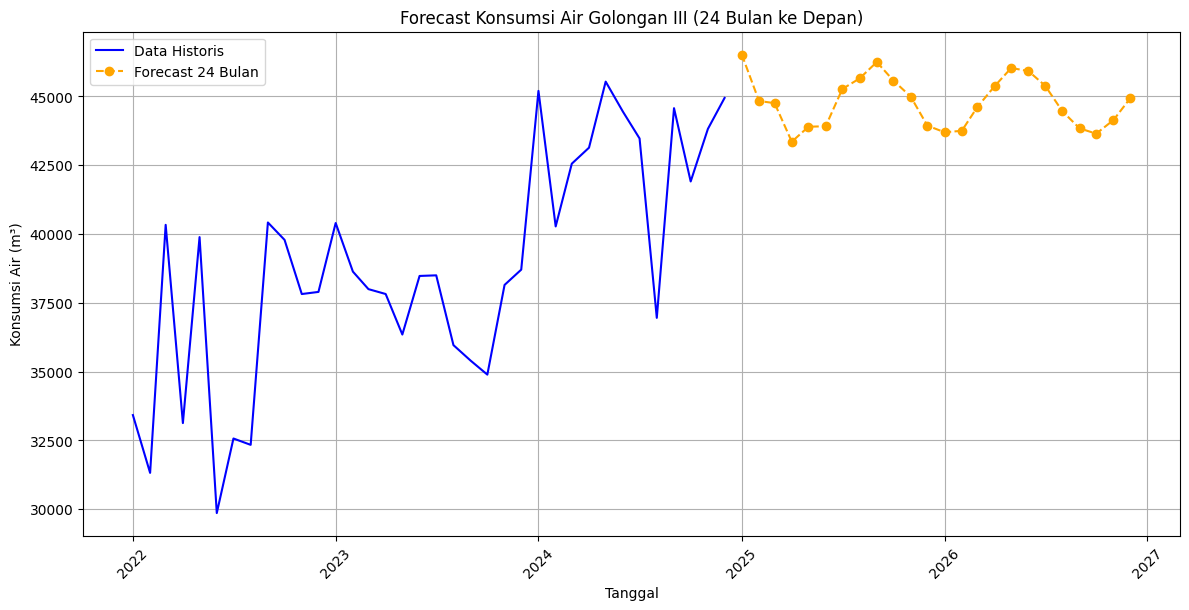

In [23]:
#Kode Visualisasi Prediksi 24 Bulan (Gabung dengan Data Historis)

import matplotlib.pyplot as plt

# Gabungkan data historis dan prediksi ke satu grafik
plt.figure(figsize=(12, 6))

# Plot data historis
plt.plot(df['GOLONGAN III'], label='Data Historis', color='blue')

# Plot prediksi 24 bulan ke depan
plt.plot(forecast_df_24['Tanggal'], forecast_df_24['Prediksi Konsumsi Air'],
         label='Forecast 24 Bulan', color='orange', linestyle='--', marker='o')

# Tambahan styling
plt.title('Forecast Konsumsi Air Golongan III (24 Bulan ke Depan)')
plt.xlabel('Tanggal')
plt.ylabel('Konsumsi Air (m³)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()


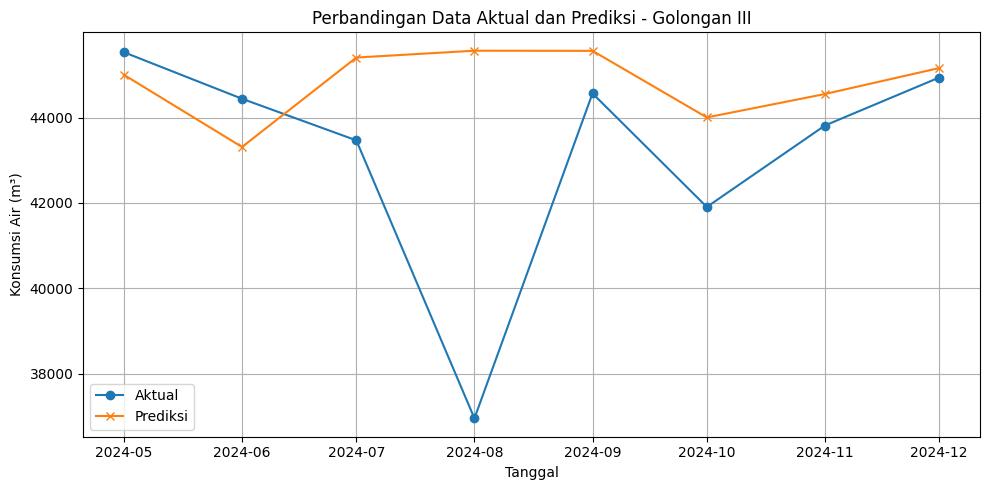

In [24]:
#Line Plot Perbandingan Data Aktual vs Prediksi


plt.figure(figsize=(10, 5))
plt.plot(test_gol3.index, test_gol3, label='Aktual', marker='o')
plt.plot(test_gol3.index, forecast_test, label='Prediksi', marker='x')
plt.title('Perbandingan Data Aktual dan Prediksi - Golongan III')
plt.xlabel('Tanggal')
plt.ylabel('Konsumsi Air (m³)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


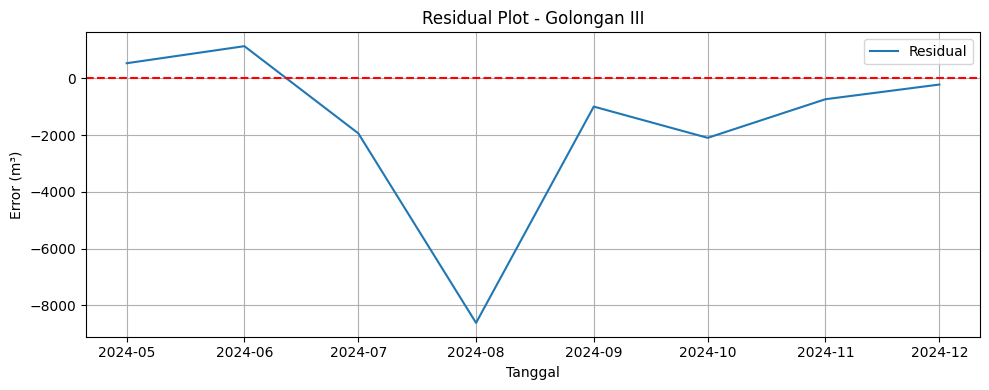

In [25]:
#Plot Residual (Error Prediksi)
#Untuk menunjukkan seberapa jauh prediksi menyimpang dari data asli

residuals = test_gol3 - forecast_test

plt.figure(figsize=(10, 4))
plt.plot(residuals, label='Residual')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot - Golongan III')
plt.xlabel('Tanggal')
plt.ylabel('Error (m³)')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()


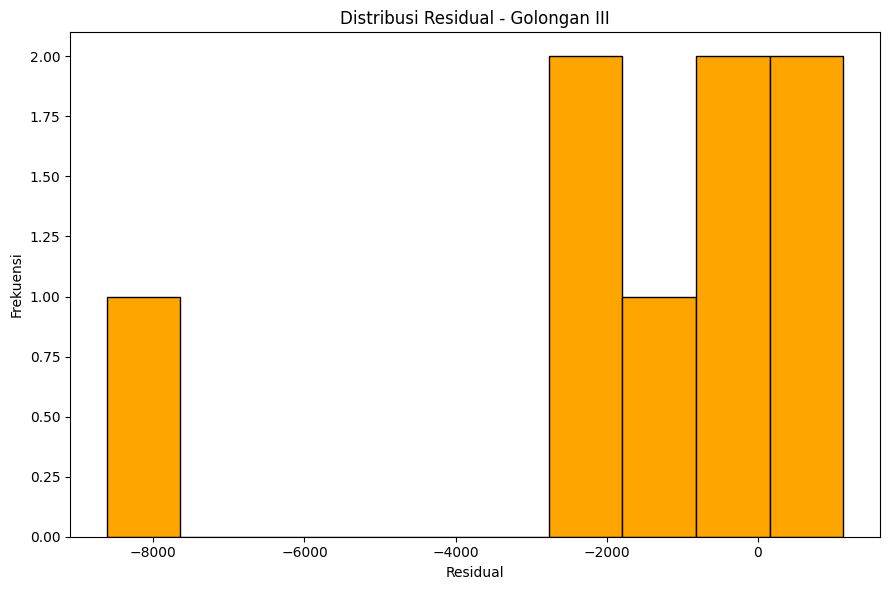

In [26]:
#Histogram Residuals
#Buat analisis distribusi kesalahan prediksi

plt.figure(figsize=(9,6))
plt.hist(residuals, bins=10, color='orange', edgecolor='black')
plt.title('Distribusi Residual - Golongan III')
plt.xlabel('Residual')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()


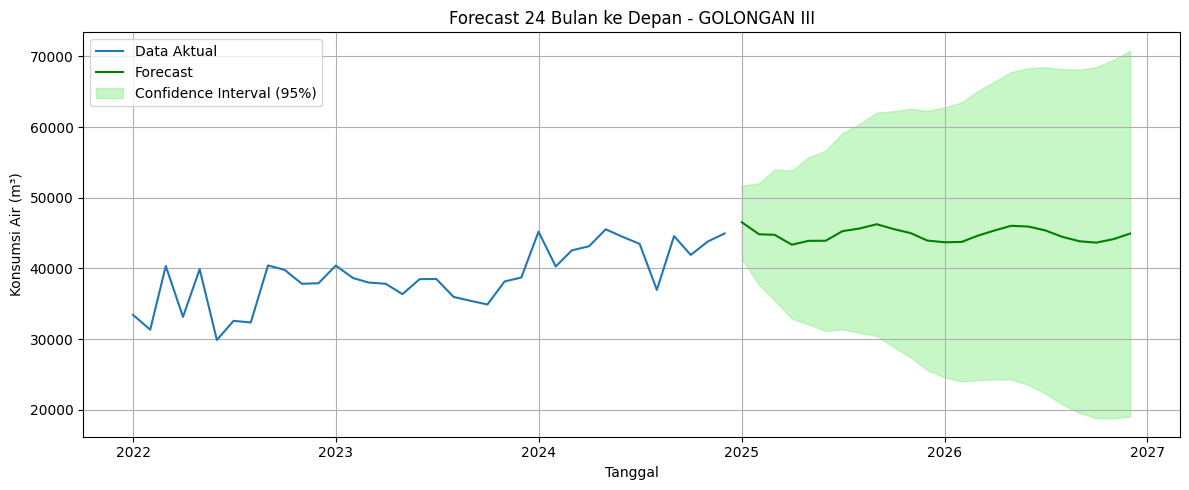

In [27]:
#Forecast + Confidence Interval (CI) untuk menunjukkan ada ketidakpastian di masa depan


pred_ci = full_model_fit.get_forecast(steps=24).conf_int()
forecast_mean = forecast_24

plt.figure(figsize=(12, 5))
plt.plot(df.index, df['GOLONGAN III'], label='Data Aktual')
plt.plot(forecast_df_24['Tanggal'], forecast_mean, label='Forecast', color='green')
plt.fill_between(forecast_df_24['Tanggal'], pred_ci.iloc[:, 0], pred_ci.iloc[:, 1],
                 color='lightgreen', alpha=0.5, label='Confidence Interval (95%)')
plt.title('Forecast 24 Bulan ke Depan - GOLONGAN III')
plt.xlabel('Tanggal')
plt.ylabel('Konsumsi Air (m³)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


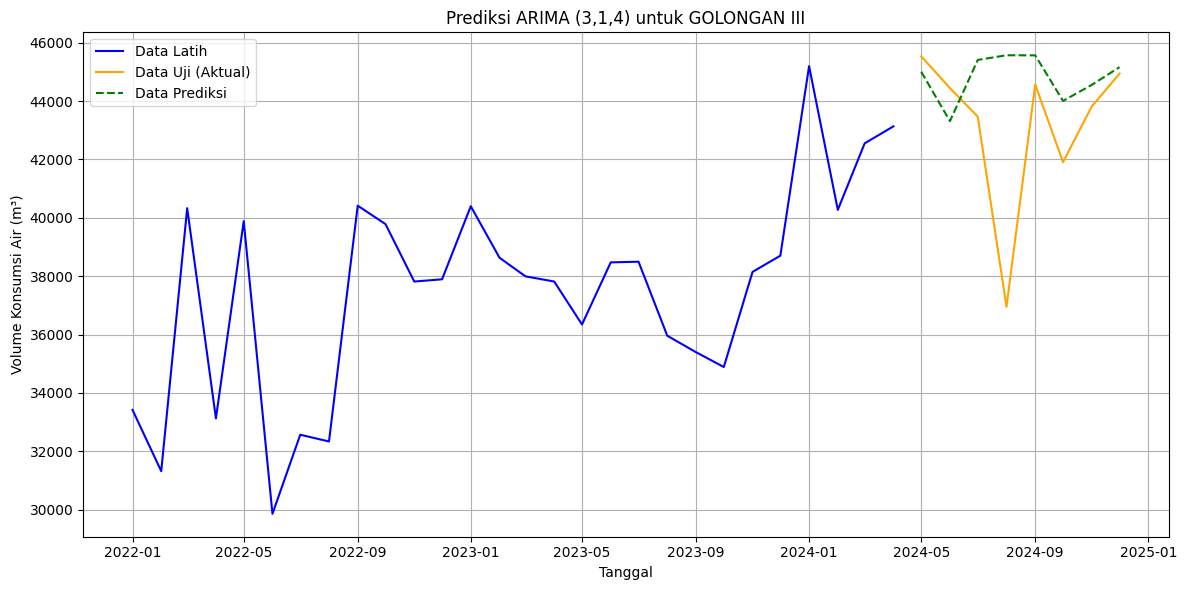

In [28]:
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# Gunakan data yang sudah disiapkan
train = df.loc[:'2024-04-01', 'GOLONGAN III']
test = df.loc['2024-05-01':, 'GOLONGAN III']

# Fit model ARIMA
model = ARIMA(train, order=(3, 1, 4))
model_fit = model.fit()

# Prediksi sebanyak panjang data test
prediksi_uji = model_fit.forecast(steps=len(test))

# Visualisasi
plt.figure(figsize=(12, 6))
plt.plot(train, label='Data Latih', color='blue')
plt.plot(test, label='Data Uji (Aktual)', color='orange')
plt.plot(test.index, prediksi_uji, label='Data Prediksi', color='green', linestyle='--')

plt.title('Prediksi ARIMA (3,1,4) untuk GOLONGAN III')
plt.xlabel('Tanggal')
plt.ylabel('Volume Konsumsi Air (m³)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
